In [1]:
# === Cell 1 — literature allometries as functions (Survey-sourced; ESD in µm) ===
import numpy as np
def esd_to_vol(esd):                      # sphere, µm -> µm³
    return (np.pi / 6.0) * np.asarray(esd, float) ** 3

# ---- μ_max [d⁻¹] vs phyto ESD (~20°C) ----
def mu_banas(e):        return 2.6  * e ** -0.45                 # Banas 2011 T2 (←Tang); Survey §3 L74
def mu_ward_diatom(e):  return 3.8  * esd_to_vol(e) ** -0.15     # Ward 2012 T2, a_diatom=3.8; §3 L75
def mu_dutk_diatom(e):  return 3.9  * esd_to_vol(e) ** -0.08     # Dutkiewicz 2020 T-S2 diatom; §3 L81
def mu_dutk_picoprok(e):return 0.9  * esd_to_vol(e) **  0.08     # Dutkiewicz 2020 pico-prok (+exp!); §3 L81
def mu_taniguchi(e):    return 1.36 * e ** -0.16                 # Taniguchi 2014 T1; §3 L72
def mu_maranon(e):                                              # Marañón (MS3-as-built ESD form); §3 L79
    e = np.asarray(e, float)
    return np.where(e <= 5.38, 0.33 * e ** 0.57, 1.83 * e ** -0.45)

# ---- K_s [mmol N m⁻³] vs phyto ESD (all nitrogen units) ----
def ks_banas(e):        return 0.1   * e ** 1.0                  # Banas 2011 T2 (Eppley); Survey §4 L103
def ks_ward_dutk(e):    return 0.17  * esd_to_vol(e) ** 0.27     # Ward2012 / Dutk2020 k_NO3; §4 L102,107
def ks_maranon_aksnes(e):return 0.144* e ** 0.81                # Marañón×Aksnes-Egge synth; §4 L101
def ks_taniguchi(e):    return 0.33  * e ** 0.48                 # Taniguchi 2014 T1; §4 L99

# ---- I_max [d⁻¹] vs ZOO ESD ----
def imax_banas(e):      return 26.0  * e ** -0.40                # Banas 2011 T2; Survey §6 L140
def imax_ward(e):       return 21.9  * esd_to_vol(e) ** -0.16    # Ward 2012 T2; §6 L141
def imax_dutk(e):                                               # Dutkiewicz 2020 T-S2; §6 L143
    e = np.asarray(e, float)
    return np.where(e > 30.0, 30.9 * esd_to_vol(e) ** -0.16, 9.8)
def imax_taniguchi(e):  return 33.96 * e ** -0.66               # Taniguchi 2014 T1; §6 (microzoo-only)

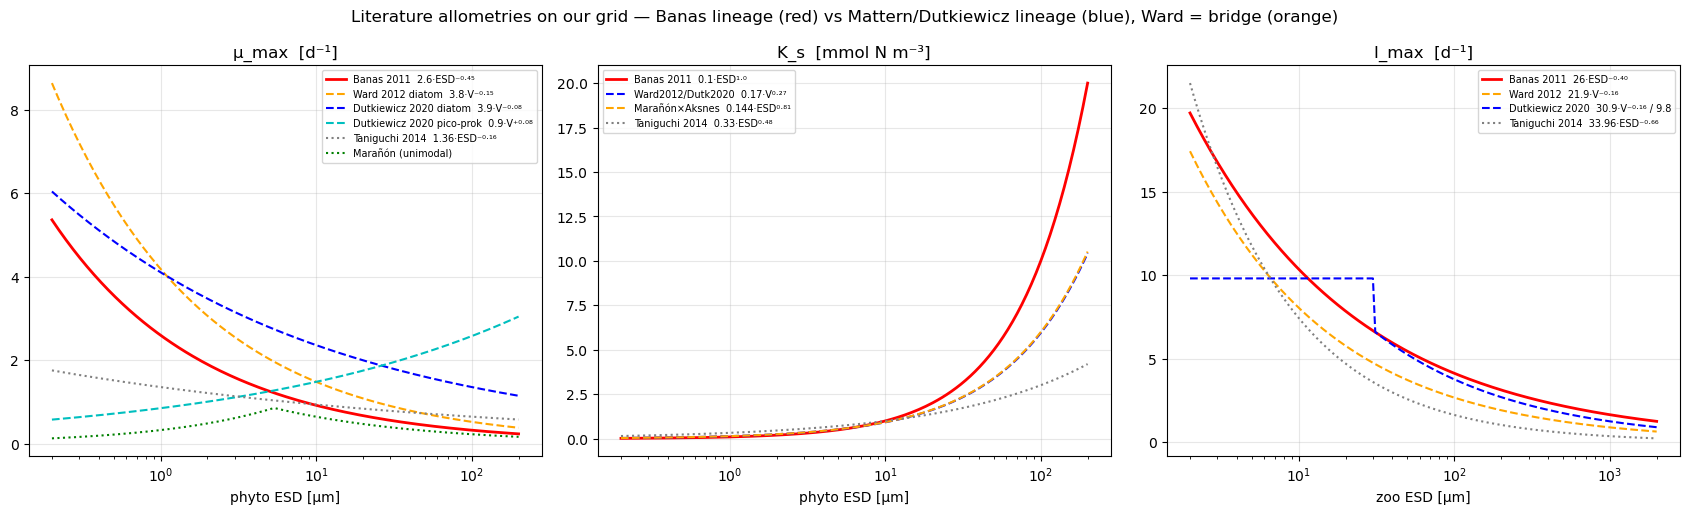

In [2]:
# === Cell 2 — allometry overview: same parameter per subplot, two lineages ===
import matplotlib.pyplot as plt
PHYTO_MIN, PHYTO_MAX, R = 0.2, 200.0, 10.0          # = our default grid extent
p = np.logspace(np.log10(PHYTO_MIN), np.log10(PHYTO_MAX), 200)      # phyto ESD
z = np.logspace(np.log10(PHYTO_MIN*R), np.log10(PHYTO_MAX*R), 200)  # zoo ESD

# style: Banas lineage = solid red; Ward (bridge) = orange dash; Mattern/Dutk = blue dash; historical = grey/green dot
fig, ax = plt.subplots(1, 3, figsize=(17, 5.2))

ax[0].plot(p, mu_banas(p),        'r-',  lw=2, label='Banas 2011  2.6·ESD⁻⁰·⁴⁵')
ax[0].plot(p, mu_ward_diatom(p),  '--',  c='orange', label='Ward 2012 diatom  3.8·V⁻⁰·¹⁵')
ax[0].plot(p, mu_dutk_diatom(p),  'b--', label='Dutkiewicz 2020 diatom  3.9·V⁻⁰·⁰⁸')
ax[0].plot(p, mu_dutk_picoprok(p),'c--', label='Dutkiewicz 2020 pico-prok  0.9·V⁺⁰·⁰⁸')
ax[0].plot(p, mu_taniguchi(p),    ':',   c='grey',  label='Taniguchi 2014  1.36·ESD⁻⁰·¹⁶')
ax[0].plot(p, mu_maranon(p),      ':',   c='green', label='Marañón (unimodal)')
ax[0].set_title('μ_max  [d⁻¹]'); ax[0].set_xlabel('phyto ESD [µm]')

ax[1].plot(p, ks_banas(p),         'r-',  lw=2, label='Banas 2011  0.1·ESD¹·⁰')
ax[1].plot(p, ks_ward_dutk(p),     'b--', label='Ward2012/Dutk2020  0.17·V⁰·²⁷')
ax[1].plot(p, ks_maranon_aksnes(p),'--',  c='orange', label='Marañón×Aksnes  0.144·ESD⁰·⁸¹')
ax[1].plot(p, ks_taniguchi(p),     ':',   c='grey',  label='Taniguchi 2014  0.33·ESD⁰·⁴⁸')
ax[1].set_title('K_s  [mmol N m⁻³]'); ax[1].set_xlabel('phyto ESD [µm]')

ax[2].plot(z, imax_banas(z),     'r-',  lw=2, label='Banas 2011  26·ESD⁻⁰·⁴⁰')
ax[2].plot(z, imax_ward(z),      '--',  c='orange', label='Ward 2012  21.9·V⁻⁰·¹⁶')
ax[2].plot(z, imax_dutk(z),      'b--', label='Dutkiewicz 2020  30.9·V⁻⁰·¹⁶ / 9.8')
ax[2].plot(z, imax_taniguchi(z), ':',   c='grey',  label='Taniguchi 2014  33.96·ESD⁻⁰·⁶⁶')
ax[2].set_title('I_max  [d⁻¹]'); ax[2].set_xlabel('zoo ESD [µm]')

for a in ax:
    a.set_xscale('log')          # size axis: log (standard for allometries / 3-decade span)
    # a.set_yscale('log')        # uncomment to straighten the power laws (compare slopes directly)
    a.legend(fontsize=7); a.grid(alpha=0.3)
fig.suptitle('Literature allometries on our grid — Banas lineage (red) vs Mattern/Dutkiewicz lineage (blue), Ward = bridge (orange)')
plt.tight_layout(); plt.show()